In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

%matplotlib inline

In [51]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

scheme = pd.read_csv("../data/processed/scheme_performance_clean.csv")

print(nav.shape)
print(scheme.shape)

(46000, 3)
(40, 19)


# Daily Returns

Daily Return = NAV_t / NAV_t-1 - 1

In [52]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = nav.groupby(
    "amfi_code"
)["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [53]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

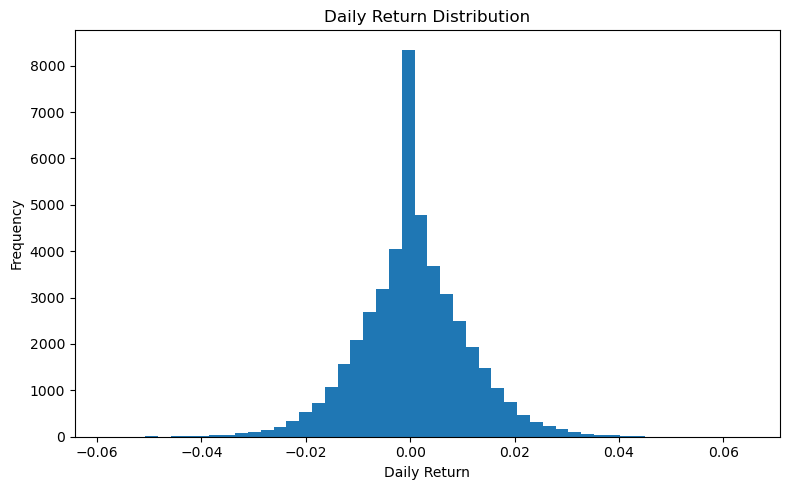

In [54]:
plt.figure(figsize=(8,5))

plt.hist(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

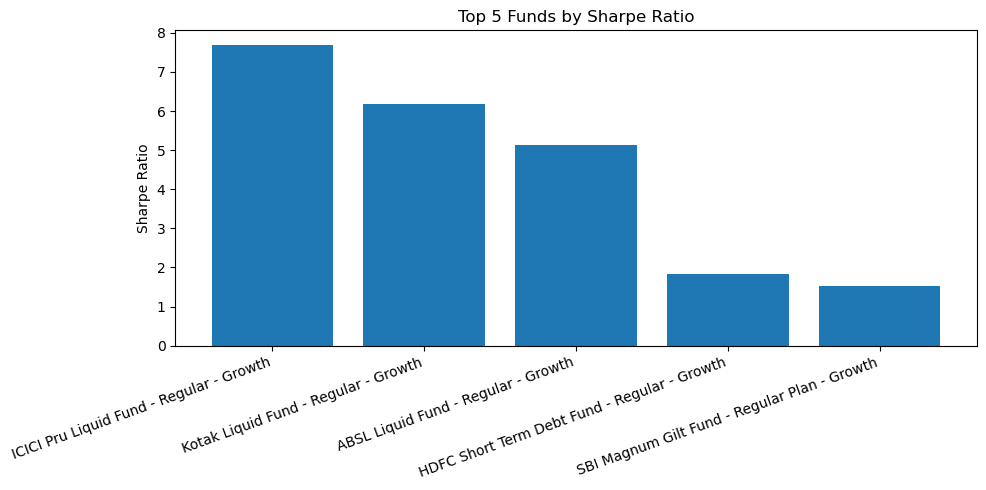

In [55]:
top5 = sharpe.head(5)

plt.figure(figsize=(10,5))

plt.bar(
    top5["scheme_name"],
    top5["sharpe_ratio"]
)

plt.xticks(rotation=20, ha="right")
plt.ylabel("Sharpe Ratio")
plt.title("Top 5 Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig("../reports/sharpe_ranking.png", dpi=300, bbox_inches="tight")

plt.show()

# Sortino Ratio

Sortino Ratio measures risk-adjusted return using only downside volatility.

In [56]:
sortino = perf.sort_values(
    by="sortino_ratio",
    ascending=False
)[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "sortino_ratio"
]]

sortino.head()

,amfi_code,scheme_name,fund_house,sortino_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,10.37
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,9.70
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,8.76
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,2.79
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,2.38


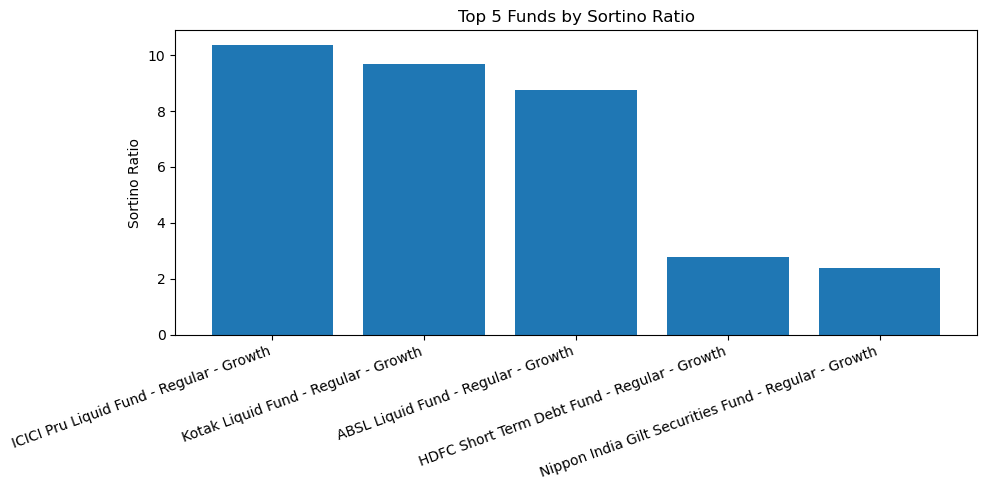

In [57]:
top5 = sortino.head(5)

plt.figure(figsize=(10,5))

plt.bar(
    top5["scheme_name"],
    top5["sortino_ratio"]
)

plt.xticks(rotation=20, ha="right")
plt.ylabel("Sortino Ratio")
plt.title("Top 5 Funds by Sortino Ratio")

plt.tight_layout()

plt.savefig(
    r"C:\Users\garav\OneDrive\Desktop\Mutual funds\reports\sortino_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Alpha and Beta

Alpha measures excess return.
Beta measures market sensitivity.

In [58]:
alpha_beta = perf.sort_values(
    by="alpha",
    ascending=False
)[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "alpha",
    "beta"
]]

alpha_beta.head()

,amfi_code,scheme_name,fund_house,alpha,beta
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,1.98,0.44
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,1.91,1.00
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,1.85,0.26
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,1.85,0.95
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,1.84,0.97


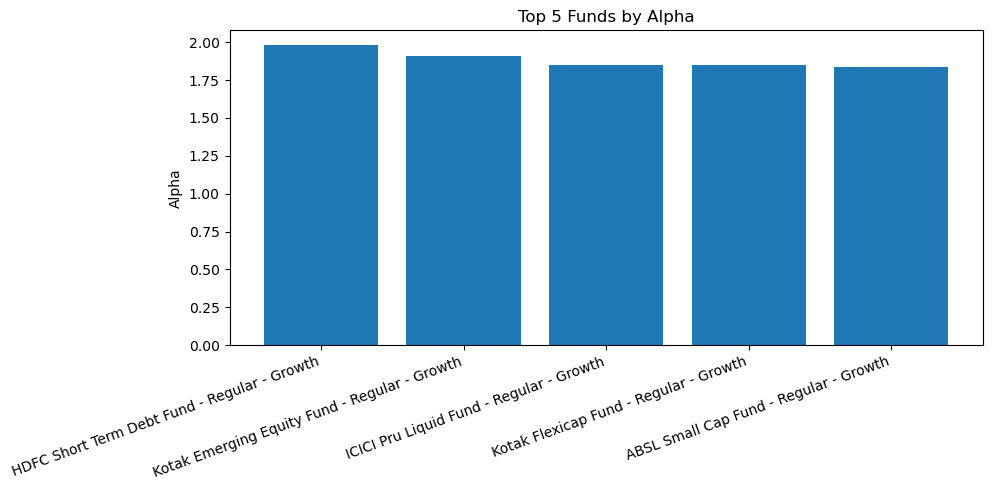

In [59]:
top5 = alpha_beta.head(5)

plt.figure(figsize=(10,5))

plt.bar(
    top5["scheme_name"],
    top5["alpha"]
)

plt.xticks(rotation=20, ha="right")
plt.ylabel("Alpha")
plt.title("Top 5 Funds by Alpha")

plt.tight_layout()

plt.savefig(
    r"C:\Users\garav\OneDrive\Desktop\Mutual funds\reports\alpha_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

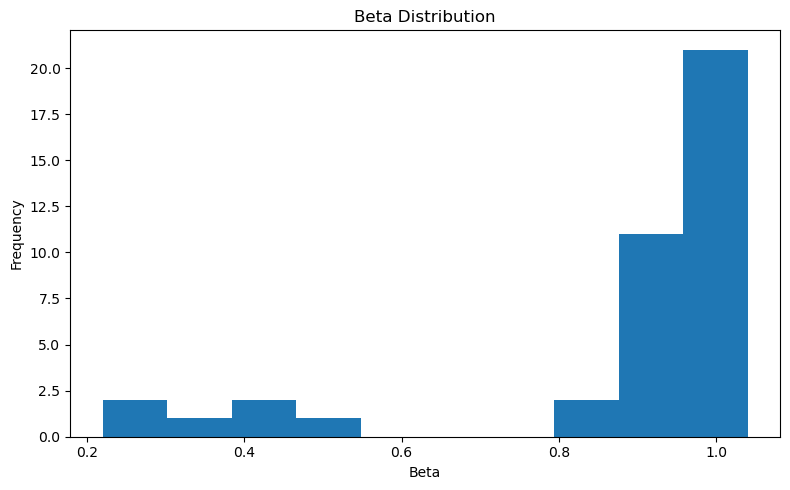

In [60]:
plt.figure(figsize=(8,5))

plt.hist(
    perf["beta"].dropna(),
    bins=10
)

plt.xlabel("Beta")
plt.ylabel("Frequency")
plt.title("Beta Distribution")

plt.tight_layout()

plt.savefig(
    r"C:\Users\garav\OneDrive\Desktop\Mutual funds\reports\beta_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

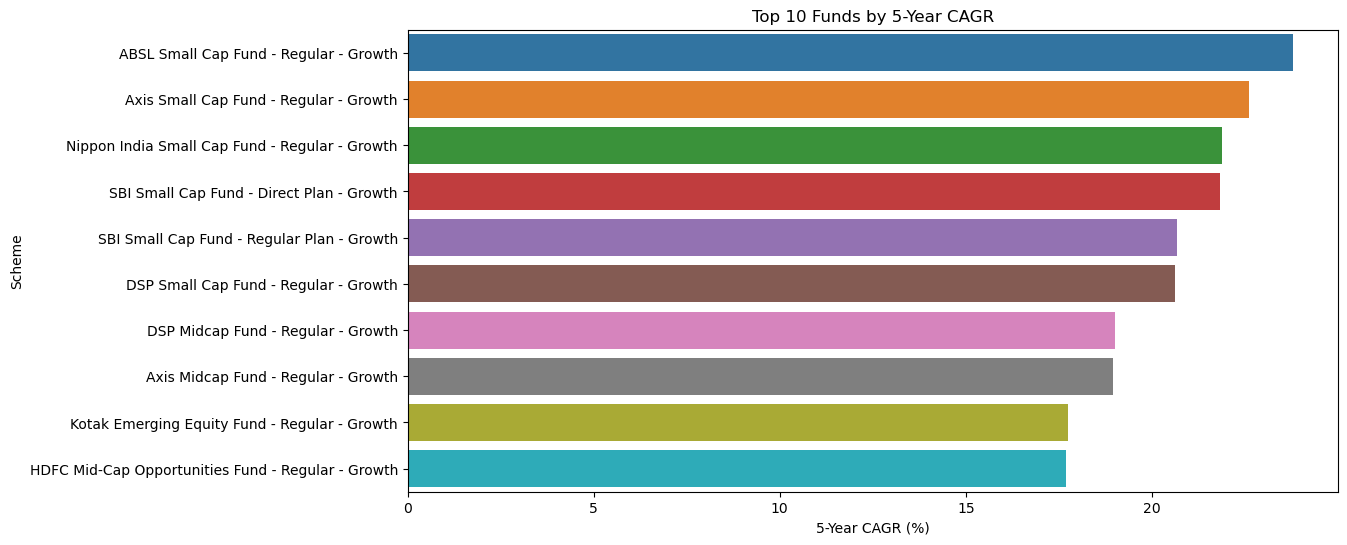

In [15]:
top10 = cagr_table.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year CAGR")
plt.xlabel("5-Year CAGR (%)")
plt.ylabel("Scheme")

plt.show()

# Save Alpha Beta Report

In [62]:
alpha_beta.to_csv(
    r"C:\Users\garav\OneDrive\Desktop\Mutual funds\reports\alpha_beta.csv",
    index=False
)

# Maximum Drawdown

Maximum Drawdown measures the largest decline from a fund's peak NAV.

In [64]:
drawdown = perf.sort_values(
    by="max_drawdown_pct"
)[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "max_drawdown_pct"
]]

drawdown.head()

,amfi_code,scheme_name,fund_house,max_drawdown_pct
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,-33.50
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,-33.15
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,-32.38
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,-32.22
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,-30.87


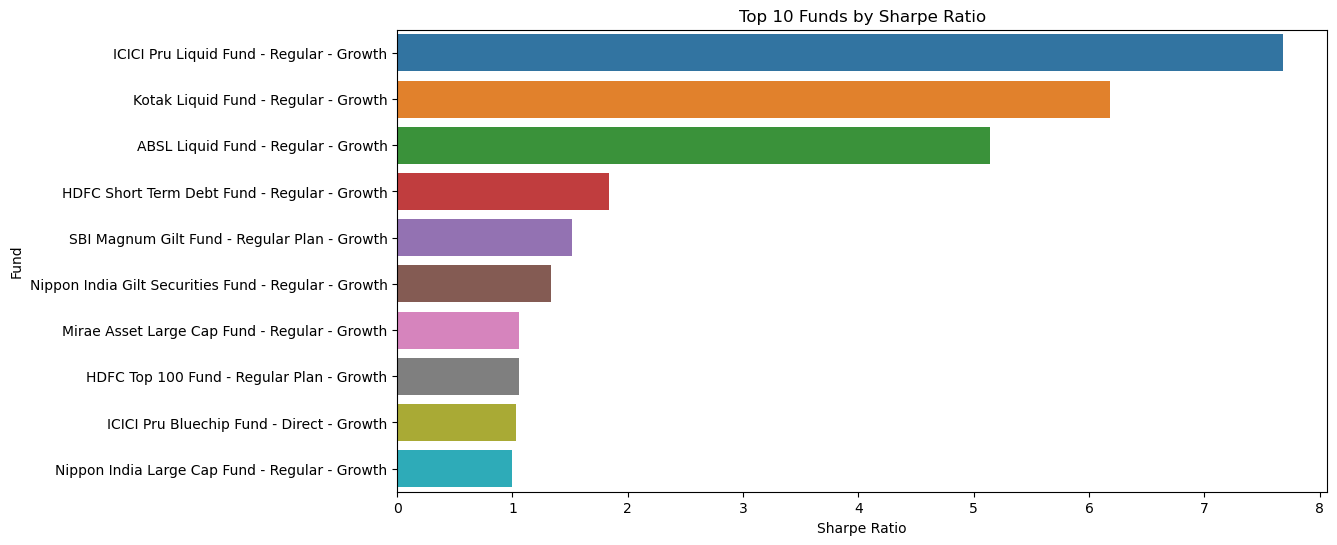

In [65]:
top10_sharpe = sharpe_rank.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Fund")

plt.show()

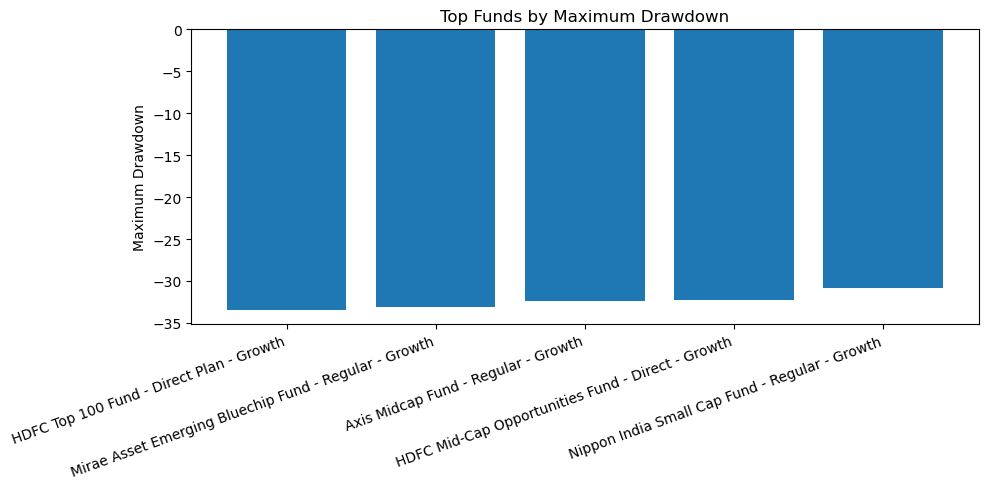

In [66]:
top5 = drawdown.head(5)

plt.figure(figsize=(10,5))

plt.bar(
    top5["scheme_name"],
    top5["max_drawdown_pct"]
)

plt.xticks(rotation=20, ha="right")
plt.ylabel("Maximum Drawdown")
plt.title("Top Funds by Maximum Drawdown")

plt.tight_layout()

plt.savefig(
    r"C:\Users\garav\OneDrive\Desktop\Mutual funds\reports\max_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Fund Scorecard

Composite Score:
- 30% Return Rank
- 25% Sharpe Rank
- 20% Alpha Rank
- 15% Expense Ratio Rank
- 10% Maximum Drawdown Rank

In [67]:
score = perf.copy()

score["return_rank"] = score["return_3yr_pct"].rank(ascending=False)

score["sharpe_rank"] = score["sharpe_ratio"].rank(ascending=False)

score["alpha_rank"] = score["alpha"].rank(ascending=False)

score["expense_rank"] = score["expense_ratio_pct"].rank()

score["drawdown_rank"] = score["max_drawdown_pct"].rank(ascending=False)

score["fund_score"] = (
    0.30*score["return_rank"] +
    0.25*score["sharpe_rank"] +
    0.20*score["alpha_rank"] +
    0.15*score["expense_rank"] +
    0.10*score["drawdown_rank"]
)

score = score.sort_values(
    by="fund_score"
)

score.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,35012,1.45,5,Moderately High,11.0,12.0,3.5,22.0,20.0,12.30
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,19259,1.43,5,Very High,1.0,18.0,20.0,21.0,8.0,12.75
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,39116,0.74,5,Low,35.0,1.0,3.5,7.0,3.0,12.80
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,27953,0.56,3,Low,36.0,4.0,1.0,2.0,6.0,12.90
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,47469,1.56,4,High,7.0,15.0,2.0,33.0,25.0,13.70


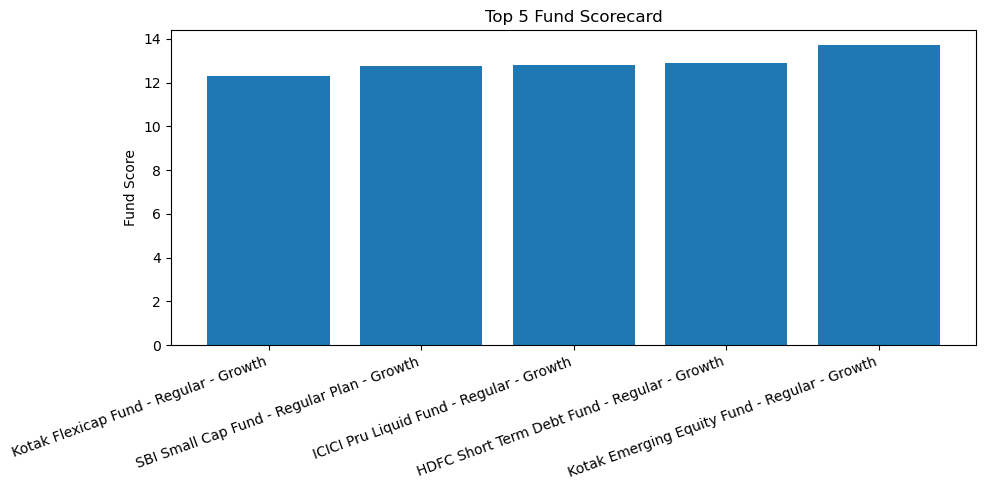

In [68]:
top5 = score.head(5)

plt.figure(figsize=(10,5))

plt.bar(
    top5["scheme_name"],
    top5["fund_score"]
)

plt.xticks(rotation=20, ha="right")
plt.ylabel("Fund Score")
plt.title("Top 5 Fund Scorecard")

plt.tight_layout()

plt.savefig(
    r"C:\Users\garav\OneDrive\Desktop\Mutual funds\reports\fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Benchmark Comparison

Compare Top 5 funds against benchmark returns.

In [69]:
benchmark = perf.sort_values(
    by="return_3yr_pct",
    ascending=False
).head(5)

benchmark[[
    "scheme_name",
    "return_3yr_pct",
    "benchmark_3yr_pct"
]]

,scheme_name,return_3yr_pct,benchmark_3yr_pct
2,SBI Small Cap Fund - Regular Plan - Growth,23.39,22.16
3,SBI Small Cap Fund - Direct Plan - Growth,23.14,22.01
29,ABSL Small Cap Fund - Regular - Growth,22.38,20.54
27,Axis Small Cap Fund - Regular - Growth,20.98,20.47
17,Nippon India Small Cap Fund - Regular - Growth,20.15,19.35


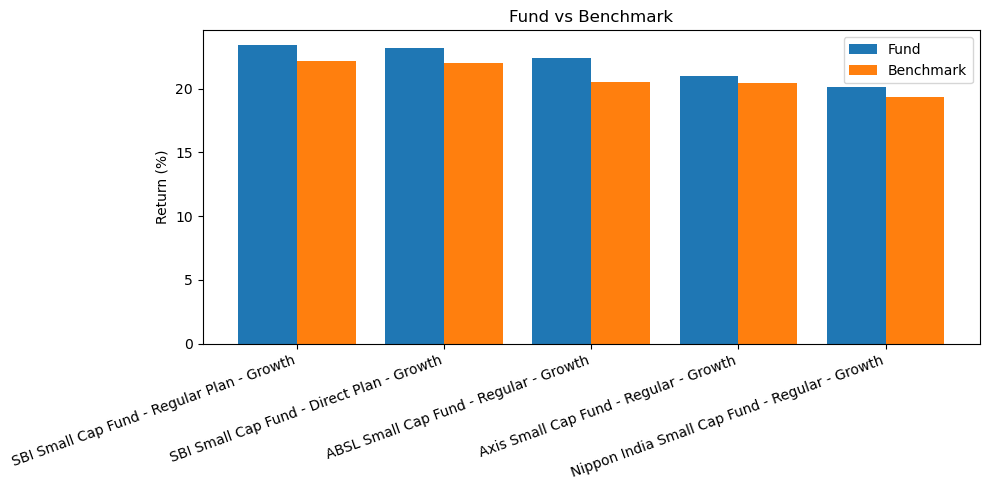

In [70]:
x = np.arange(len(benchmark))

plt.figure(figsize=(10,5))

plt.bar(
    x-0.2,
    benchmark["return_3yr_pct"],
    width=0.4,
    label="Fund"
)

plt.bar(
    x+0.2,
    benchmark["benchmark_3yr_pct"],
    width=0.4,
    label="Benchmark"
)

plt.xticks(
    x,
    benchmark["scheme_name"],
    rotation=20,
    ha="right"
)

plt.ylabel("Return (%)")
plt.title("Fund vs Benchmark")

plt.legend()

plt.tight_layout()

plt.savefig(
    r"C:\Users\garav\OneDrive\Desktop\Mutual funds\reports\benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Tracking Error

In [72]:
benchmark["tracking_error"] = abs(
    benchmark["return_3yr_pct"] -
    benchmark["benchmark_3yr_pct"]
)

benchmark[[
    "scheme_name",
    "tracking_error"
]]

,scheme_name,tracking_error
2,SBI Small Cap Fund - Regular Plan - Growth,1.23
3,SBI Small Cap Fund - Direct Plan - Growth,1.13
29,ABSL Small Cap Fund - Regular - Growth,1.84
27,Axis Small Cap Fund - Regular - Growth,0.51
17,Nippon India Small Cap Fund - Regular - Growth,0.80


# Export Reports

In [73]:
score.to_csv(
    r"C:\Users\garav\OneDrive\Desktop\Mutual funds\reports\fund_scorecard.csv",
    index=False
)

alpha_beta.to_csv(
    r"C:\Users\garav\OneDrive\Desktop\Mutual funds\reports\alpha_beta.csv",
    index=False
)

benchmark.to_csv(
    r"C:\Users\garav\OneDrive\Desktop\Mutual funds\reports\benchmark_comparison.csv",
    index=False
)

drawdown.to_csv(
    r"C:\Users\garav\OneDrive\Desktop\Mutual funds\reports\max_drawdown.csv",
    index=False
)

sortino.to_csv(
    r"C:\Users\garav\OneDrive\Desktop\Mutual funds\reports\sortino_ranking.csv",
    index=False
)

# Conclusion

This notebook computed:

- Daily Returns
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha and Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison
- Tracking Error

Generated Deliverables:

- Performance_Analytics.ipynb
- fund_scorecard.csv
- alpha_beta.csv
- benchmark_comparison.png